Centering is done to prevent an extra matrix like μμ⊤ from appearing when computing the covariance. Although you could subtract it out via other steps, this way seems more convenient for now.

$$
\mathbb{E}[xx^{\top}]
=\mathbb{E}\big[(x-\mu+\mu)(x-\mu+\mu)^{\top}\big]
=\mathrm{Cov}(x)+\mu\mu^{\top}.
$$

The cov_matrix takes the centered matrix and, through some operations, turns it into a matrix that’s easier to analyze.

$$
{{Cov}}(x)=\frac{1}{T}\,X_c X_c^{\top}
$$

Below is the idea behind whitening and how to construct it.

$$
\textbf{Goal:}\quad X_w = KX_c,\qquad \frac{1}{T}X_wX_w^\top = I_k
$$

$$
\frac{1}{T}X_wX_w^\top
=\frac{1}{T}(KX_c)(KX_c)^\top
=K\Big(\frac{1}{T}X_cX_c^\top\Big)K^\top
=KCK^\top
$$

$$
\text{So we need}\quad KCK^\top = I_k.
$$

$$
C=\frac{1}{T}X_cX_c^\top,\qquad
C=E\Lambda E^\top,\quad \Lambda=\mathrm{diag}(\lambda_1,\dots,\lambda_n),\ \lambda_1\ge\cdots\ge 0
$$

$$
E_k=[e_1,\dots,e_k],\qquad
\Lambda_k=\mathrm{diag}(\lambda_1,\dots,\lambda_k)
$$

$$
\text{Choose}\quad K=\Lambda_k^{-1/2}E_k^\top
\qquad\Big(\Lambda_k^{-1/2}=\mathrm{diag}(1/\sqrt{\lambda_1},\dots,1/\sqrt{\lambda_k})\Big)
$$

$$
\Rightarrow\quad
KCK^\top
=\Lambda_k^{-1/2}E_k^\top(E\Lambda E^\top)E_k\Lambda_k^{-1/2}
=\Lambda_k^{-1/2}\Lambda_k\Lambda_k^{-1/2}
=I_k
$$

$$
d\_{stand}=\sqrt{d\_{co}},\quad
$$

$$
K=\mathrm{diag}(1/d\_{stand})\,E_{co}^\top,\qquad
X_w=KX_c
$$

A correction to the W matrix.

$$
y_1 = w_1^\top X_w,\quad y_2 = w_2^\top X_w
$$

If we don’t enforce orthogonality, then 𝑤1 could end up becoming more and more similar to 𝑤2

Let $A = WW^\top$，and define:
$$
W_{\text{new}} = A^{-1/2}W
$$

Then
$$
W_{\text{new}}W_{\text{new}}^\top
= A^{-1/2}WW^\top A^{-1/2}
= A^{-1/2}AA^{-1/2}
= I
$$

$$
A = u\,\mathrm{diag}(s)\,u^\top
\;\Rightarrow\;
A^{-1/2} = u\,\mathrm{diag}\!\left(\frac{1}{\sqrt{s}}\right)u^\top
$$

To ensure independence, we essentially need to re-apply this step after each update to 𝑊

We choose the nonlinearity $g(y)=\tanh(y)$ to approximate the score function. It is approximately linear for small amplitudes $(\tanh(y)\approx y)$ and saturates to $\pm 1\$ for large amplitudes, thereby compressing extreme values, improving the robustness of the update, and driving the unmixing matrix \(W\) to converge toward directions whose outputs are more non-Gaussian and hence more independent.”

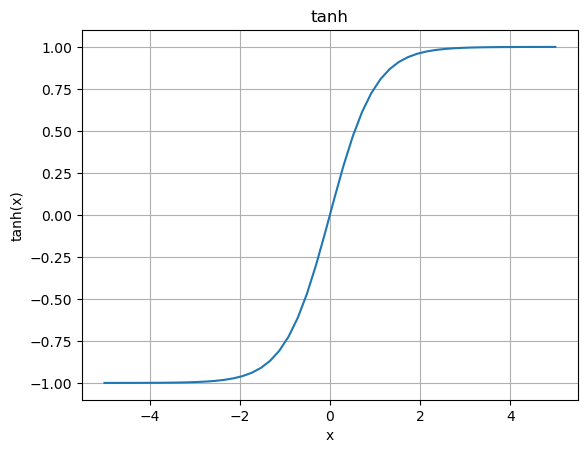

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-5, 5)
y = np.tanh(x)

plt.plot(x, y)
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.title("tanh")
plt.grid(True)
plt.show()

$$
W \leftarrow \frac{1}{T}\, g(Y)\, X_w^\top \;-\; \operatorname{diag}\!\left(\frac{1}{T}\sum_{t=1}^{T} g'(Y_{\cdot t})\right)\, W .
$$

The first term pushes 𝑊 toward directions that increase independence, while the second term uses the mean of 𝑔′as a scale correction to ensure stable iteration.

$$
\text{lim}=\max_i\left|\; \left| (W W_{\text{old}}^{\top})_{ii}\right|-1 \;\right|.
$$

After each step, we multiply the updated matrix by the previous one and compare the result to the identity matrix to measure how much the update changed 𝑊. When this difference falls below a certain threshold, it indicates that we have obtained a reasonably good 𝑊

Then we obtain the independent components S

$$
S = W X_w
$$

If we want to see a more direct relationship between 𝑆 and 𝑋, we can multiply the whitening matrix by the learned 𝑊, combining them into a single mapping for easier interpretation.

$$
S = W_{\text{full}}(X - \mu)
$$

If we want to examine the spatial distribution of 𝑆 in 𝑋, we move the unmixing matrix to the other side, which gives the mixing matrix 𝐴 that we’re more familiar with.

$$
A = W_{\text{full}}^{\dagger} \approx W_{\text{full}}^{-1}.
$$

$$
X - \mu \approx AS
$$

And that's the end, hahahaha